In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
breast_cancer = sklearn.datasets.load_breast_cancer()

In [ ]:
data = pd.DataFrame(data=breast_cancer.data, columns =breast_cancer.feature_names)

In [ ]:
data['label']= pd.DataFrame(breast_cancer.target)

In [ ]:
data.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
data.shape

(569, 31)

In [ ]:
print('Duplites values:',data.duplicated().sum())
print('Null values:',data.isnull().sum().sum())

Duplites values: 0
Null values: 0


# 1- Beginine
# 0- Malignant

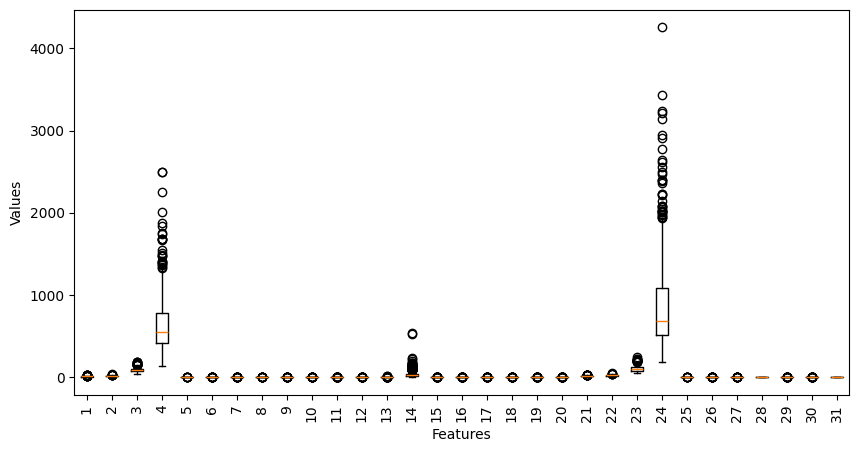

In [ ]:
plt.figure(figsize=(10,5))
plt.boxplot(x=data)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

# Remove Outliers
# Not performing it will remove the data which have 0 target values
for i in data.columns:
  if data[i].dtype =='float64' or data[i].dtype =='int64':
    Q1= data[i].quantile(0.25)
    Q3= data[i].quantile(0.75)
    IQR = Q3-Q1
    LF = Q1 - 1.5*IQR
    UF =Q3 + 1.5*IQR
    data = data[(data[i]>=LF) & (data[i]<=UF)]
  

In [ ]:
# Seperate the data
x= data.drop(columns ='label', axis=1)
y= data['label']

In [ ]:
# spliting the data into training and testing datasets

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [ ]:
print(f'Shape of x_train:',x_train.shape)
print(f'Shape of x_test:',x_test.shape)
print(f'Shape of y_train:',y_train.shape)
print(f'Shape of y_test:',y_test.shape)

Shape of x_train: (455, 30)
Shape of x_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


In [ ]:
# from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
LR_model= LogisticRegression()

In [ ]:
LR_model.fit(x_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = LR_model.predict(x_test_scaled)
y_pred

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0])

In [ ]:
  print('R2_score:', r2_score(y_pred, y_test))
  print('MAE:', mean_absolute_error(y_pred, y_test))
  print('MSE:', mean_squared_error(y_pred, y_test))
  print('Accuracy:', accuracy_score(y_pred, y_test))
  print('Precision:', precision_score(y_pred, y_test))
  print('Recall:', recall_score(y_pred, y_test))

R2_score: 0.8906649616368286
MAE: 0.02631578947368421
MSE: 0.02631578947368421
Accuracy: 0.9736842105263158
Precision: 0.9710144927536232
Recall: 0.9852941176470589


Text(33.22222222222222, 0.5, 'Truth')

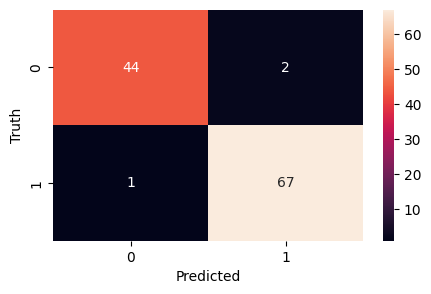

In [ ]:
plt.figure(figsize=(5,3))
plt.cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Decision Tree regressor model

In [ ]:
DT_model = DecisionTreeClassifier()

In [ ]:
y_pred_DT = DT_model.fit(x_train_scaled, y_train).predict(x_test_scaled)

In [ ]:
DT_model.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_DT =DT_model.predict(x_test_scaled)
y_pred_DT

array([1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0])

In [ ]:
  print('R2_score:', r2_score(y_pred_DT, y_test))
  print('MAE:', mean_absolute_error(y_pred_DT, y_test))
  print('MSE:', mean_squared_error(y_pred_DT, y_test))
  print('Accuracy:', accuracy_score(y_pred_DT, y_test))
  print('Precision:', precision_score(y_pred_DT, y_test))
  print('Recall:', recall_score(y_pred_DT, y_test))

R2_score: 0.6793750000000001
MAE: 0.07894736842105263
MSE: 0.07894736842105263
Accuracy: 0.9210526315789473
Precision: 0.8985507246376812
Recall: 0.96875


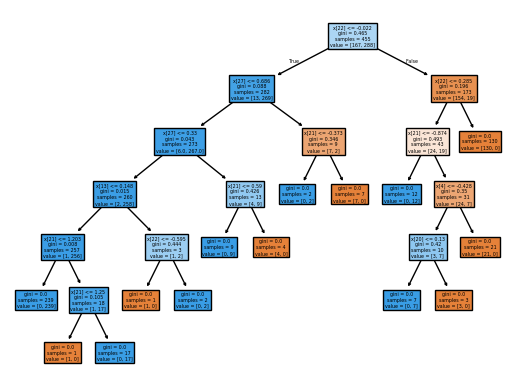

In [ ]:
from sklearn import tree
final_tree = tree.plot_tree(DT_model, filled =True)

# Random Forest classifier

In [ ]:
RF_model = RandomForestClassifier(n_estimators=40)

In [ ]:
RF_model.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=40)

In [ ]:
y_pred_RF =RF_model.predict(x_test_scaled)
y_pred_RF

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0])

In [ ]:
  print('R2_score:', r2_score(y_pred_RF, y_test))
  print('MAE:', mean_absolute_error(y_pred_RF, y_test))
  print('MSE:', mean_squared_error(y_pred_RF, y_test))
  print('Accuracy:', accuracy_score(y_pred_RF, y_test))
  print('Precision:', precision_score(y_pred_RF, y_test))
  print('Recall:', recall_score(y_pred_RF, y_test))

R2_score: 0.7448849104859335
MAE: 0.06140350877192982
MSE: 0.06140350877192982
Accuracy: 0.9385964912280702
Precision: 0.9420289855072463
Recall: 0.9558823529411765


In [ ]:
print("mean_squared_error Performance")
print("LR MSE:" ,mean_squared_error(y_pred, y_test))
print("DT MSE:" ,mean_squared_error(y_pred_DT, y_test))
print("RF MSE:" ,mean_squared_error(y_pred_RF, y_test))

mean_squared_error Performance
LR MSE: 0.02631578947368421
DT MSE: 0.07894736842105263
RF MSE: 0.06140350877192982


In [ ]:
print("mean_absolute_error Performance")
print("LR MAE:" ,mean_absolute_error(y_pred, y_test))
print("DT MAE:" ,mean_absolute_error(y_pred_DT, y_test))
print("RF MAE:" ,mean_absolute_error(y_pred_RF, y_test))

mean_absolute_error Performance
LR MAE: 0.02631578947368421
DT MAE: 0.07894736842105263
RF MAE: 0.06140350877192982


In [ ]:
print("R2_score Performance")
print("LR R2_score:" ,r2_score(y_pred, y_test))
print("DT R2_score:" ,r2_score(y_pred_DT, y_test))
print("RF R2_score:" ,r2_score(y_pred_RF, y_test))

R2_score Performance
LR R2_score: 0.8906649616368286
DT R2_score: 0.6793750000000001
RF R2_score: 0.7448849104859335


In [ ]:
print("accuracy_score Performance")
print("LR accuracy:" ,accuracy_score(y_pred, y_test))
print("DT accuracy:" ,accuracy_score(y_pred_DT, y_test))
print("RF accuracy:" ,accuracy_score(y_pred_RF, y_test))

accuracy_score Performance
LR accuracy: 0.9736842105263158
DT accuracy: 0.9210526315789473
RF accuracy: 0.9385964912280702


# Building a predicted system (for future predication)

In [125]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)



In [126]:
# convert into array
input_data_arr = np.asarray(input_data)

# reshape
input_data_reshape = input_data_arr.reshape(1,-1)

In [127]:
y_pred

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0])

In [129]:
prediction = LR_model.predict(input_data_reshape)
print(prediction)

if(prediction==1):
  print('The breast cancer is Benign')
else:
  print('The breast cancer is Malignant')

[0]
The breast cancer is Malignant
